## Exploratory Data Analysis: Formula 1 Overview (1950–2025)

This notebook provides a high-level exploratory overview of the Formula 1 dataset covering races from 1950 to 2025.

The goal of this analysis is not to evaluate driver or team performance in detail, but rather to understand the overall structure and evolution of Formula 1 as a competition over time. Specifically, we focus on how the championship calendar expanded, how the set of circuits evolved, and how constructors are distributed by nationality.

This notebook addresses the following questions:

- How has the number of races per season changed over time?

- How has the number racers and constructors changed over the time?

- What is the nationality distribution of constructors in Formula 1?

The analysis is intentionally kept descriptive and lightweight, serving as contextual groundwork for deeper analytical and machine learning tasks in subsequent notebooks.

In [50]:
from copyreg import constructor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data

In [51]:
races = load_data('races')
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [52]:
races_by_year = races.groupby('year').size().reset_index(name='count')
races_by_year

,year,count
0,1950,7
1,1951,8
2,1952,8
3,1953,9
4,1954,9
...,...,...
71,2021,22
72,2022,22
73,2023,22
74,2024,24


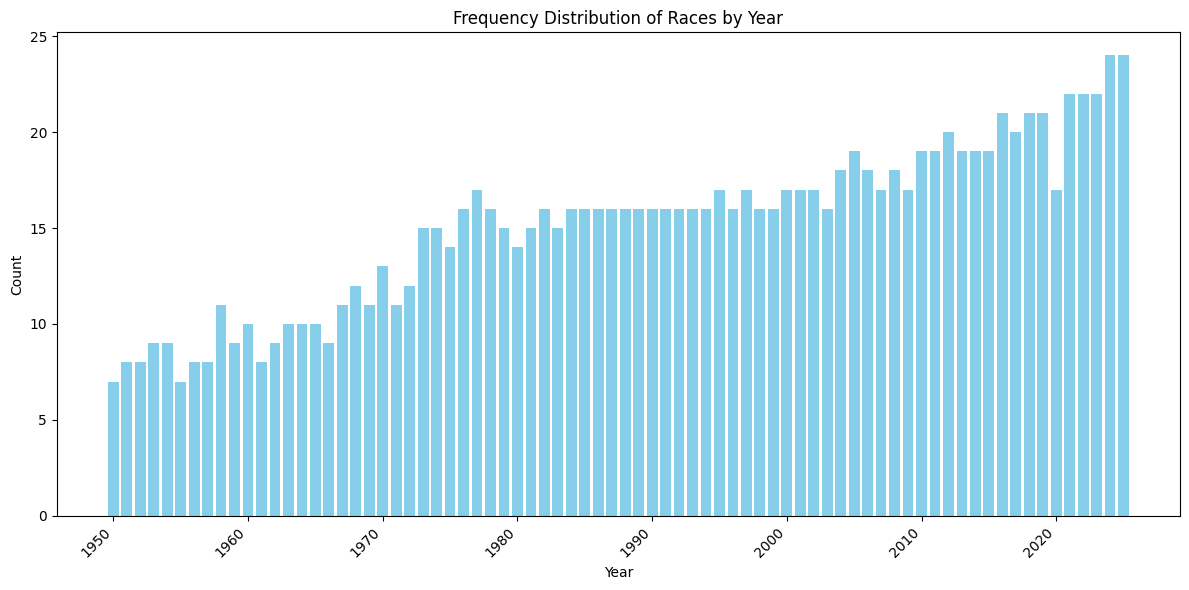

In [53]:
plt.figure(figsize=(12, 6))
plt.bar(races_by_year['year'], races_by_year['count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Frequency Distribution of Races by Year")
plt.tight_layout()

In [54]:
drivers_by_year = (
    results
    .merge(races[['raceId', 'year']], on='raceId')
    .groupby('year')['driverId']
    .nunique()
)
drivers_by_year


year
1950     81
1951     84
1952    105
1953    108
1954     97
       ... 
2021     21
2022     22
2023     22
2024     24
2025     21
Name: driverId, Length: 76, dtype: int64

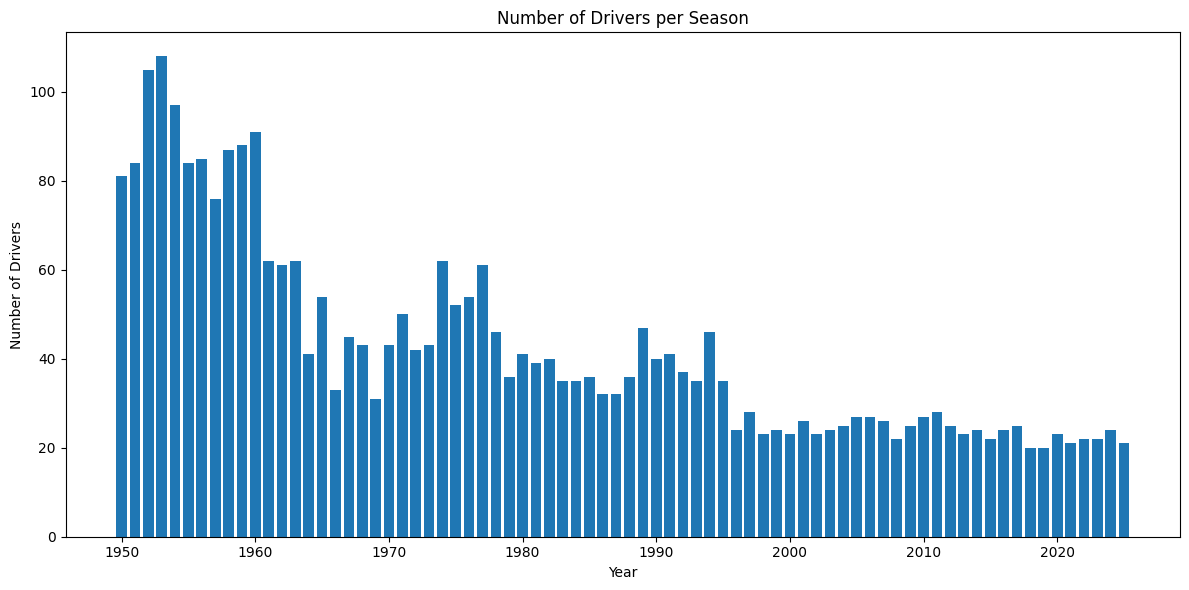

In [55]:
plt.figure(figsize=(12, 6))
plt.bar(drivers_by_year.index, drivers_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Drivers")
plt.title("Number of Drivers per Season")
plt.tight_layout()
plt.show()


In [56]:
constructors_by_year = (
    results
    .merge(races[['raceId', 'year']], on='raceId')
    .groupby('year')['constructorId']
    .nunique()
)

constructors_by_year

year
1950    24
1951    24
1952    25
1953    21
1954    19
        ..
2021    10
2022    10
2023    10
2024    10
2025    10
Name: constructorId, Length: 76, dtype: int64

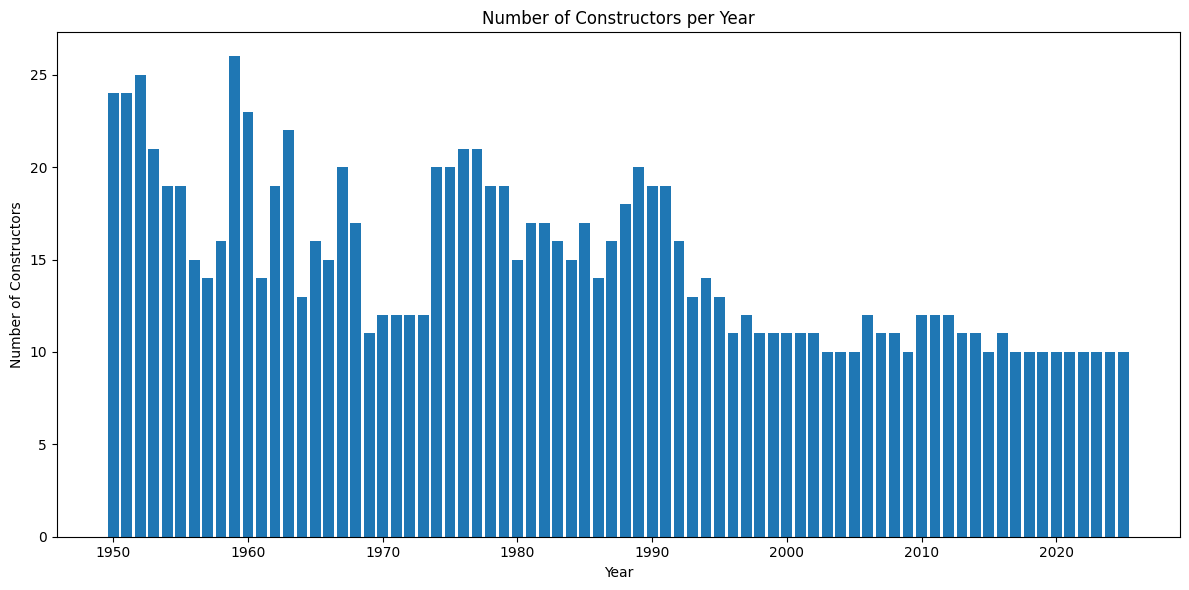

In [57]:
plt.figure(figsize=(12, 6))
plt.bar(constructors_by_year.index, constructors_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Constructors")
plt.title("Number of Constructors per Year")
plt.tight_layout()
plt.show()

In [58]:
drivers_df = drivers_by_year.reset_index()
drivers_df.columns = ['year', 'drivers']

constructors_df = constructors_by_year.reset_index()
constructors_df.columns = ['year', 'constructors']


drivers_and_constructors_by_year = drivers_df.merge(
    constructors_df,
    on='year',
    how='left'
)


drivers_and_constructors_by_year

,year,drivers,constructors
0,1950,81,24
1,1951,84,24
2,1952,105,25
3,1953,108,21
4,1954,97,19
...,...,...,...
71,2021,21,10
72,2022,22,10
73,2023,22,10
74,2024,24,10


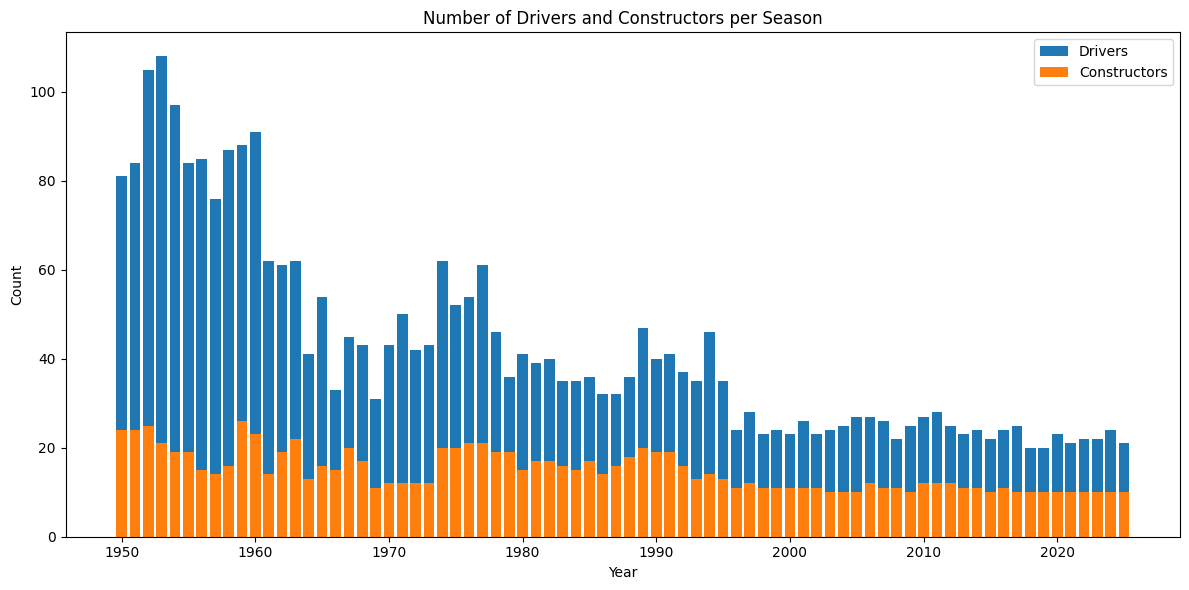

In [59]:
plt.figure(figsize=(12, 6))

plt.bar(
    drivers_and_constructors_by_year['year'],
    drivers_and_constructors_by_year['drivers'],
    label='Drivers'
)

plt.bar(
    drivers_and_constructors_by_year['year'],
    drivers_and_constructors_by_year['constructors'],
    label='Constructors'
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Number of Drivers and Constructors per Season")
plt.legend()
plt.tight_layout()
plt.show()


In [60]:
drivers = load_data('drivers')
constructors = load_data('constructors')

constructors_by_nationality = (
    constructors['nationality']
    .value_counts()
)

drivers_by_nationality = (
    drivers['nationality']
    .value_counts()
)

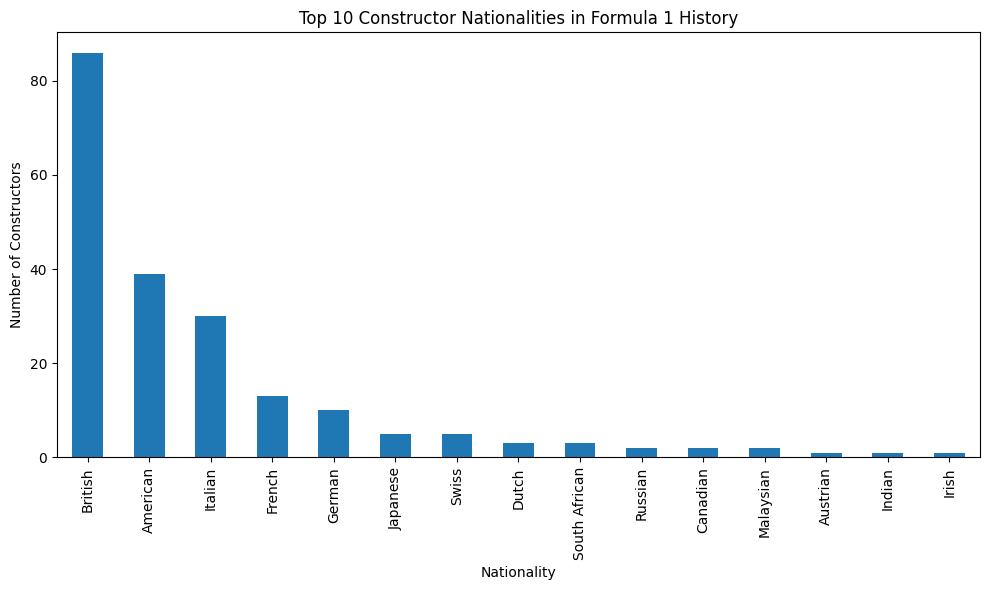

In [61]:
top_n = 15

plt.figure(figsize=(10, 6))
constructors_by_nationality.head(top_n).plot(kind='bar')
plt.xlabel("Nationality")
plt.ylabel("Number of Constructors")
plt.title("Top 10 Constructor Nationalities in Formula 1 History")
plt.tight_layout()
plt.show()

In [62]:
constructors_by_nationality

nationality
British          86
American         39
Italian          30
French           13
German           10
Japanese          5
Swiss             5
Dutch             3
South African     3
Russian           2
Canadian          2
Malaysian         2
Austrian          1
Indian            1
Irish             1
Hong Kong         1
Brazilian         1
Mexican           1
Australian        1
New Zealander     1
Rhodesian         1
Belgian           1
East German       1
Spanish           1
Name: count, dtype: int64

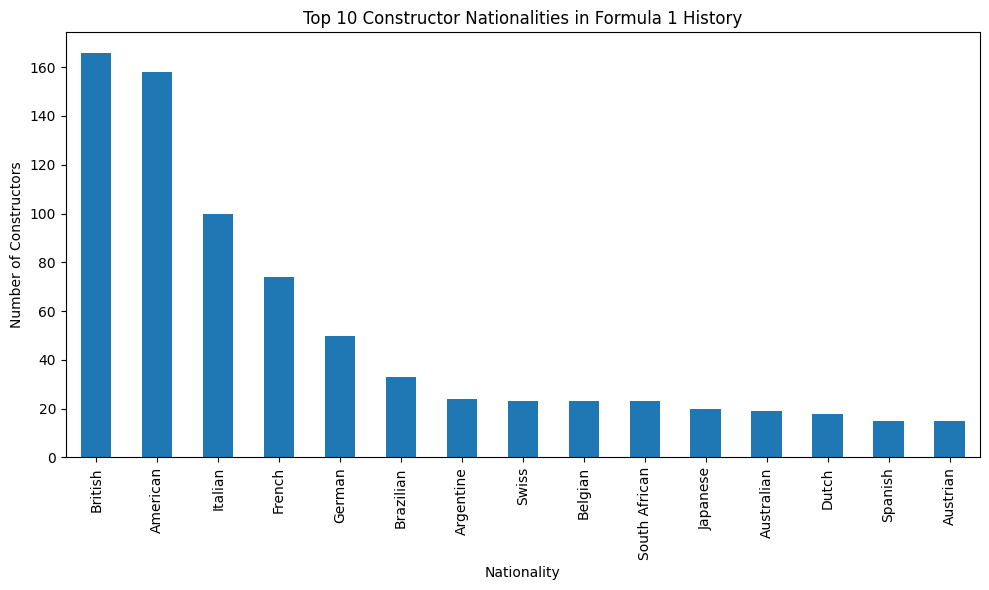

In [63]:
top_n = 15

plt.figure(figsize=(10, 6))
drivers_by_nationality.head(top_n).plot(kind='bar')
plt.xlabel("Nationality")
plt.ylabel("Number of Constructors")
plt.title("Top 10 Constructor Nationalities in Formula 1 History")
plt.tight_layout()
plt.show()

In [64]:
drivers_by_nationality

nationality
British              166
American             158
Italian              100
French                74
German                50
Brazilian             33
Argentine             24
Swiss                 23
Belgian               23
South African         23
Japanese              20
Australian            19
Dutch                 18
Spanish               15
Austrian              15
Canadian              14
Swedish               10
New Zealander         10
Finnish                9
Mexican                6
Irish                  5
Danish                 5
Portuguese             4
Monegasque             4
Rhodesian              4
Uruguayan              4
Russian                4
Colombian              3
Venezuelan             3
East German            3
Indian                 2
Thai                   2
Polish                 1
Hungarian              1
Czech                  1
Malaysian              1
Chilean                1
Liechtensteiner        1
American-Italian       1
Argentine-Ita

## ✅ Summary & Key Observations

This exploratory analysis provides a high-level overview of how Formula 1 has evolved structurally since its inception in 1950.

### Race calendar expansion.
The number of races per season has increased substantially over time. Early seasons featured fewer than 10 races, while modern championships regularly include 20+ Grands Prix, reflecting the commercial growth and global expansion of the sport. The calendar growth is not strictly linear, showing periods of stabilization and rapid expansion corresponding to regulatory and organizational changes.

### Drivers and constructors over time.
The number of drivers per season has decreased significantly compared to early decades. While early Formula 1 seasons often featured a very large pool of participating drivers, modern seasons are highly standardized, with a relatively stable grid of approximately 20–24 drivers.
A similar trend is observed for constructors, where early eras included many short-lived or private teams, whereas modern Formula 1 is characterized by a smaller, more stable set of long-term entrants. This reflects increasing financial, technical, and regulatory barriers to entry.

### Constructor nationality distribution.
The nationality distribution of constructors highlights a strong historical concentration in a small number of countries. British constructors dominate Formula 1 history by a wide margin, followed by American, Italian, French, and German teams. This pattern reflects the long-standing role of the United Kingdom as the engineering and operational center of Formula 1, as well as the historical involvement of major automotive nations.

### Overall conclusion.
At a structural level, Formula 1 has evolved from a fragmented, experimental competition into a highly regulated, capital-intensive global championship. The trends observed in race counts, participant stability, and constructor nationalities provide essential context for deeper performance analysis and predictive modeling in subsequent notebooks.